In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/playground-series-s5e1/sample_submission.csv
/kaggle/input/playground-series-s5e1/train.csv
/kaggle/input/playground-series-s5e1/test.csv


# Packages and data initialization

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
color_pal = sns.color_palette()
# DataFrame with training data
train_df = pd.read_csv('/kaggle/input/playground-series-s5e1/train.csv', parse_dates=["date"])
# DataFrame with testing data
test_df = pd.read_csv('/kaggle/input/playground-series-s5e1/test.csv',parse_dates=["date"])
print(train_df.head())
print(test_df.head())


   id       date country              store             product  num_sold
0   0 2010-01-01  Canada  Discount Stickers   Holographic Goose       NaN
1   1 2010-01-01  Canada  Discount Stickers              Kaggle     973.0
2   2 2010-01-01  Canada  Discount Stickers        Kaggle Tiers     906.0
3   3 2010-01-01  Canada  Discount Stickers            Kerneler     423.0
4   4 2010-01-01  Canada  Discount Stickers  Kerneler Dark Mode     491.0
       id       date country              store             product
0  230130 2017-01-01  Canada  Discount Stickers   Holographic Goose
1  230131 2017-01-01  Canada  Discount Stickers              Kaggle
2  230132 2017-01-01  Canada  Discount Stickers        Kaggle Tiers
3  230133 2017-01-01  Canada  Discount Stickers            Kerneler
4  230134 2017-01-01  Canada  Discount Stickers  Kerneler Dark Mode


/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


In [3]:
def create_features(df):
    """
    Create time series features based on time series index.
    """
    df = df.copy()
    df['dayofweek'] = df['date'].dt.dayofweek
    df['quarter'] = df['date'].dt.quarter
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['dayofyear'] = df['date'].dt.dayofyear
    df['dayofmonth'] = df['date'].dt.day
    df['weekofyear'] = df['date'].dt.isocalendar().week
    return df

# Outliers

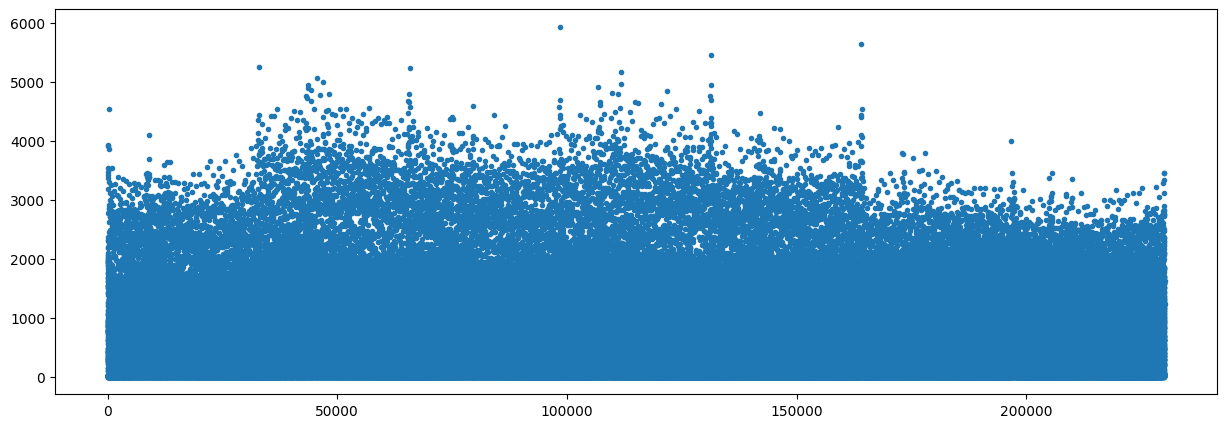

In [4]:
train_df.num_sold.plot(style='.',
             figsize=(15,5),
             color=color_pal[0])
plt.show()

# DATA transformation

In [5]:

# Función para agregar lags
def add_lags(df):
    """
    Agrega características de lag a un DataFrame de ventas.
    """
    # Asegúrate de que el DataFrame esté ordenado por fecha
    df = df.sort_values(by=['country', 'store', 'product', 'date'])

    # Crear un diccionario que mapea las fechas a 'num_sold'
    target_map = df.set_index(['country', 'store', 'product', 'date'])['num_sold'].to_dict()

    # Crear lags
    df['lag1'] = df.set_index(['country', 'store', 'product', 'date']).index.map(
        lambda x: target_map.get((x[0], x[1], x[2], x[3] - pd.DateOffset(years=1)), None)
    )
    df['lag2'] = df.set_index(['country', 'store', 'product', 'date']).index.map(
        lambda x: target_map.get((x[0], x[1], x[2], x[3] - pd.DateOffset(years=2)), None)
    )
    df['lag3'] = df.set_index(['country', 'store', 'product', 'date']).index.map(
        lambda x: target_map.get((x[0], x[1], x[2], x[3] - pd.DateOffset(years=3)), None)
    )
    df['lag4'] = df.set_index(['country', 'store', 'product', 'date']).index.map(
        lambda x: target_map.get((x[0], x[1], x[2], x[3] - pd.DateOffset(years=4)), None)
    )
    df['lag5'] = df.set_index(['country', 'store', 'product', 'date']).index.map(
        lambda x: target_map.get((x[0], x[1], x[2], x[3] - pd.DateOffset(years=5)), None)
    )
    df['lag6'] = df.set_index(['country', 'store', 'product', 'date']).index.map(
        lambda x: target_map.get((x[0], x[1], x[2], x[3] - pd.DateOffset(years=6)), None)
    )
    df['lag7'] = df.set_index(['country', 'store', 'product', 'date']).index.map(
        lambda x: target_map.get((x[0], x[1], x[2], x[3] - pd.DateOffset(years=7)), None)
    )
    df['lag8'] = df.set_index(['country', 'store', 'product', 'date']).index.map(
        lambda x: target_map.get((x[0], x[1], x[2], x[3] - pd.DateOffset(years=8)), None)
    )

    return df


In [6]:
#Create a new column to differentiate the two dataFrame and join them
train_df['isFuture'] = False
test_df['isFuture'] = True
df_merged = pd.concat([train_df, test_df])

df_merged['Time'] = df_merged.groupby(['country', 'store', 'product']).cumcount() #time-step feature
df_merged['lag1day'] = df_merged.groupby(['country', 'store', 'product'])['num_sold'].shift(1)  # 1 day lag

df_merged = create_features(df_merged)

df_merged = add_lags(df_merged)
df_merged

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pan

,id,date,country,store,product,num_sold,isFuture,Time,lag1day,dayofweek,...,dayofmonth,weekofyear,lag1,lag2,lag3,lag4,lag5,lag6,lag7,lag8
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN,False,0,NaN,4,...,1,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
90,90,2010-01-02,Canada,Discount Stickers,Holographic Goose,NaN,False,1,NaN,5,...,2,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
180,180,2010-01-03,Canada,Discount Stickers,Holographic Goose,NaN,False,2,NaN,6,...,3,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
270,270,2010-01-04,Canada,Discount Stickers,Holographic Goose,NaN,False,3,NaN,0,...,4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
360,360,2010-01-05,Canada,Discount Stickers,Holographic Goose,NaN,False,4,NaN,1,...,5,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98184,328314,2019-12-27,Singapore,Stickers for Less,Kerneler Dark Mode,NaN,True,3647,NaN,4,...,27,52,NaN,NaN,1016.0,1112.0,970.0,1031.0,913.0,856.0
98274,328404,2019-12-28,Singapore,Stickers for Less,Kerneler Dark Mode,NaN,True,3648,NaN,5,...,28,52,NaN,NaN,1062.0,969.0,1236.0,1180.0,1002.0,1063.0
98364,328494,2019-12-29,Singapore,Stickers for Less,Kerneler Dark Mode,NaN,True,3649,NaN,6,...,29,52,NaN,NaN,1178.0,993.0,1043.0,1351.0,1193.0,1106.0
98454,328584,2019-12-30,Singapore,Stickers for Less,Kerneler Dark Mode,NaN,True,3650,NaN,0,...,30,1,NaN,NaN,1357.0,1083.0,1057.0,1023.0,1233.0,1112.0


In [7]:
# making sure everything is allright
filtered_data=df_merged.copy()
filtered_data = filtered_data[
(filtered_data['country']=='Canada')&
(filtered_data['store']=="Discount Stickers") &
(filtered_data['product']=='Kaggle') &
(filtered_data['dayofyear'].isin([1,2,3,4]))]
columns_to_display = ['date','Time','num_sold', 'lag1day', 'lag1', 'lag2', 'lag3', 'lag4', 'lag5', 'lag6', 'lag7', 'lag8']
filtered_data = filtered_data[columns_to_display]
filtered_data

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,date,Time,num_sold,lag1day,lag1,lag2,lag3,lag4,lag5,lag6,lag7,lag8
1,2010-01-01,0,973.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
91,2010-01-02,1,881.0,973.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
181,2010-01-03,2,1003.0,881.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
271,2010-01-04,3,744.0,1003.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32851,2011-01-01,365,1006.0,847.0,973.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32941,2011-01-02,366,1014.0,1006.0,881.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
33031,2011-01-03,367,819.0,1014.0,1003.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
33121,2011-01-04,368,855.0,819.0,744.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65701,2012-01-01,730,1142.0,1043.0,1006.0,973.0,NaN,NaN,NaN,NaN,NaN,NaN
65791,2012-01-02,731,758.0,1142.0,1014.0,881.0,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df_merged.columns

Index(['id', 'date', 'country', 'store', 'product', 'num_sold', 'isFuture',
       'Time', 'lag1day', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear',
       'dayofmonth', 'weekofyear', 'lag1', 'lag2', 'lag3', 'lag4', 'lag5',
       'lag6', 'lag7', 'lag8'],
      dtype='object')

In [9]:
# set variable y and x for the training data
df_merged=df_merged.sort_values(by='id')
y_train = df_merged[df_merged['isFuture']==False].num_sold

In [10]:

train_df_features = ['id','isFuture','country', 'store',
                     'product','Time', 'lag1day',
                     'dayofweek', 'quarter',
                     'month','year', 'dayofyear',
                     'dayofmonth','weekofyear', 'lag1',
                     'lag2', 'lag3','lag4', 'lag5', 'lag6',
                     'lag7', 'lag8']

df_x = df_merged[train_df_features]

In [11]:
# See which columns are type categorical and store them
s = (df_x.dtypes == 'object')
object_cols = list(s[s].index)
print("Categorical variables:")
print(object_cols)

Categorical variables:
['country', 'store', 'product']


In [12]:
#Transforming the categorical variables from the test and training data into numerical
from sklearn.preprocessing import OneHotEncoder
OH_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
OH_cols_df = pd.DataFrame(OH_encoder.fit_transform(df_x[object_cols]))


In [13]:
OH_cols_df.index = df_x.index

num_x_df = df_x.drop(object_cols, axis=1)

OH_x_df = pd.concat([num_x_df, OH_cols_df], axis=1)

OH_x_df.columns = OH_x_df.columns.astype(str)


In [14]:
# Solve the NAs problems on X data
OH_x_df=OH_x_df.fillna(0)

#view the data
filtered_data2=OH_x_df.copy()
filtered_data2 = filtered_data2[
(filtered_data2['id'].isin([1,91,181,271]))]
columns_to_display = ['Time','lag1day', 'lag1', 'lag2', 'lag3', 'lag4', 'lag5', 'lag6', 'lag7', 'lag8']
filtered_data2 = filtered_data2[columns_to_display]
filtered_data2

,Time,lag1day,lag1,lag2,lag3,lag4,lag5,lag6,lag7,lag8
1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
91,1,973.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
181,2,881.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
271,3,1003.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
from sklearn.impute import SimpleImputer

# Make a copy of the original Y set
y_train_plus = y_train.copy()

# Creat new columns for the missing values
y_train_plus = y_train_plus.to_frame()  # Pass into a DataFrame
y_train_plus['num_sold_was_missing'] = y_train_plus['num_sold'].isnull()

# Select only the numerical columns for imputation
imputer = SimpleImputer()
imputed_values = imputer.fit_transform(y_train_plus[['num_sold']])  

# Rebuild the DataFrame with imputated values
imputed_y_train_plus = pd.DataFrame(imputed_values, columns=['num_sold'], index=y_train_plus.index)

# Add the columns with the missing values
imputed_y_train_plus['num_sold_was_missing'] = y_train_plus['num_sold_was_missing']
# Delete the column 'num_sold_was_missing'
imputed_y_train_plus = imputed_y_train_plus.drop(columns=['num_sold_was_missing'])
imputed_y_train_plus = pd.DataFrame(imputed_y_train_plus)
imputed_y_train_plus.describe()

,num_sold
count,230130.000000
mean,752.527382
std,676.732490
min,5.000000
25%,230.000000
50%,633.000000
75%,1084.000000
max,5939.000000


In [16]:
#Make sure there isn't no NAs
print(imputed_y_train_plus.isnull().sum())  # It should be 0
imputed_y_train_plus.head()

num_sold    0
dtype: int64


,num_sold
0,752.527382
1,973.000000
2,906.000000
3,423.000000
4,491.000000


In [17]:
print(OH_x_df.isnull().sum())  # It should be 0


id            0
isFuture      0
Time          0
lag1day       0
dayofweek     0
quarter       0
month         0
year          0
dayofyear     0
dayofmonth    0
weekofyear    0
lag1          0
lag2          0
lag3          0
lag4          0
lag5          0
lag6          0
lag7          0
lag8          0
0             0
1             0
2             0
3             0
4             0
5             0
6             0
7             0
8             0
9             0
10            0
11            0
12            0
13            0
dtype: int64


In [18]:
OH_x_df.columns

Index(['id', 'isFuture', 'Time', 'lag1day', 'dayofweek', 'quarter', 'month',
       'year', 'dayofyear', 'dayofmonth', 'weekofyear', 'lag1', 'lag2', 'lag3',
       'lag4', 'lag5', 'lag6', 'lag7', 'lag8', '0', '1', '2', '3', '4', '5',
       '6', '7', '8', '9', '10', '11', '12', '13'],
      dtype='object')

In [19]:
imputed_x_train_plus = OH_x_df[OH_x_df['isFuture']==False].drop(['id', 'isFuture'], axis=1)
imputed_x_test_plus = OH_x_df[OH_x_df['isFuture']==True].drop(['id', 'isFuture'], axis=1)

In [20]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.model_selection import train_test_split


# Definir el modelo
model = XGBRegressor()

# Definir la cuadrícula de parámetros
#param_grid = {
#   'learning_rate': [0.2,0.3,0.4],
#    'max_depth': [8,9,10],
#    'gamma': [0,0.25],
#    'reg_lambda': [0,1.0],
#    'scale_pos_weight': [1,3],
#    'n_estimators': [100,200],

#}

#param_grid = {
#   'learning_rate': [0.1,0.2],
#    'max_depth': [10,11,12],
#    'gamma': [0.25, 0.5],
#    'reg_lambda': [1.0,2.0],
#    'scale_pos_weight': [1],
#    'n_estimators': [50,100],
#}

#param_grid = {
#   'learning_rate': [0.1],
#    'max_depth': [12, 13, 14],
#    'gamma': [0.25],
#    'reg_lambda': [2.0, 3.0, 4.0],
#    'scale_pos_weight': [1],
#    'n_estimators': [100],
#}
#param_grid = {
 #  'learning_rate': [0.1],
#    'max_depth': [12],
#    'gamma': [0.25],
#    'reg_lambda': [3.0],
#    'scale_pos_weight': [1],
#    'n_estimators': [100],
#}
#X_train, X_valid, y_train, y_valid = train_test_split(imputed_x_train_plus, imputed_y_train_plus, test_size=0.2, random_state=42)

# Configurar la validación cruzada
#kfold = KFold(n_splits=10, shuffle=True, random_state=7)

# Configurar la búsqueda en cuadrícula
#grid_search = GridSearchCV(model, param_grid, scoring="neg_mean_absolute_error", n_jobs=-1, cv=kfold)

# Ajustar el modelo
#grid_result = grid_search.fit(imputed_x_train_plus, imputed_y_train_plus.num_sold,
#             early_stopping_rounds=5, 
#             eval_set=[(X_valid, y_valid)],
#             verbose=False)

# Resumir resultados
#print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
#means = grid_result.cv_results_['mean_test_score']
#stds = grid_result.cv_results_['std_test_score']
#params = grid_result.cv_results_['params']
#for mean, stdev, param in zip(means, stds, params):
#    print("%f (%f) with: %r" % (mean, stdev, param))

In [21]:
import xgboost as xgb
from sklearn.model_selection import train_test_split

# Supongamos que tienes tus datos en X e y
X_train, X_valid, y_train, y_valid = train_test_split(imputed_x_train_plus, imputed_y_train_plus, test_size=0.2, random_state=42)


#Fit the model 
from xgboost import XGBRegressor

StickerModel = XGBRegressor(
    learning_rate=0.1,
    max_depth=12,
    gamma=0.25,
    reg_lambda=3.0,
    scale_pos_weight=1,
    n_estimators=100,
    random_state=42
)
StickerModel.fit(imputed_x_train_plus, imputed_y_train_plus.num_sold,
             early_stopping_rounds=5, 
             eval_set=[(X_valid, y_valid)],
             verbose=False)



/usr/local/lib/python3.10/dist-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=0.25, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=12, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [22]:
predictions = StickerModel.predict(imputed_x_test_plus)
print(predictions.shape)  

(98550,)


In [23]:
test_df_copy = pd.DataFrame(test_df.copy()) 
test_df_copy['num_sold'] = StickerModel.predict(imputed_x_test_plus)

In [24]:
test_df_copy[['id', 'num_sold']].to_csv('Forecasting_Sticker_sale9', index=False)

In [25]:
df_merged.columns

Index(['id', 'date', 'country', 'store', 'product', 'num_sold', 'isFuture',
       'Time', 'lag1day', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear',
       'dayofmonth', 'weekofyear', 'lag1', 'lag2', 'lag3', 'lag4', 'lag5',
       'lag6', 'lag7', 'lag8'],
      dtype='object')

In [26]:
columns_lag=['lag1', 'lag2', 'lag3', 'lag4', 'lag5',
       'lag6', 'lag7', 'lag8']
col_im= imputed_x_train_plus.columns

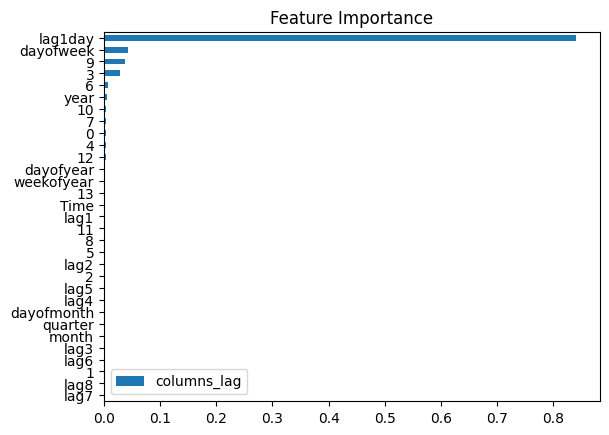

In [27]:
fi2 = pd.DataFrame(data=StickerModel.feature_importances_,
             index=StickerModel.feature_names_in_,
             columns=['columns_lag'])
fi2.sort_values('columns_lag').plot(kind='barh', title='Feature Importance')
plt.show()

In [28]:
y_predic= StickerModel.predict(X_valid)
print(y_predic.shape,y_valid['num_sold'].shape)  

(46026,) (46026,)
